# Name: LY Laisrun
# ID: e20230616

In [14]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

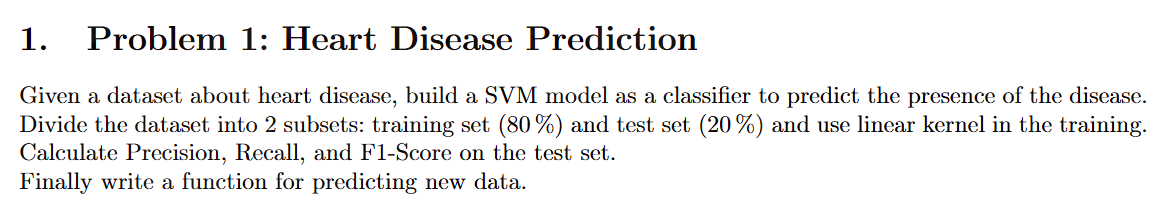

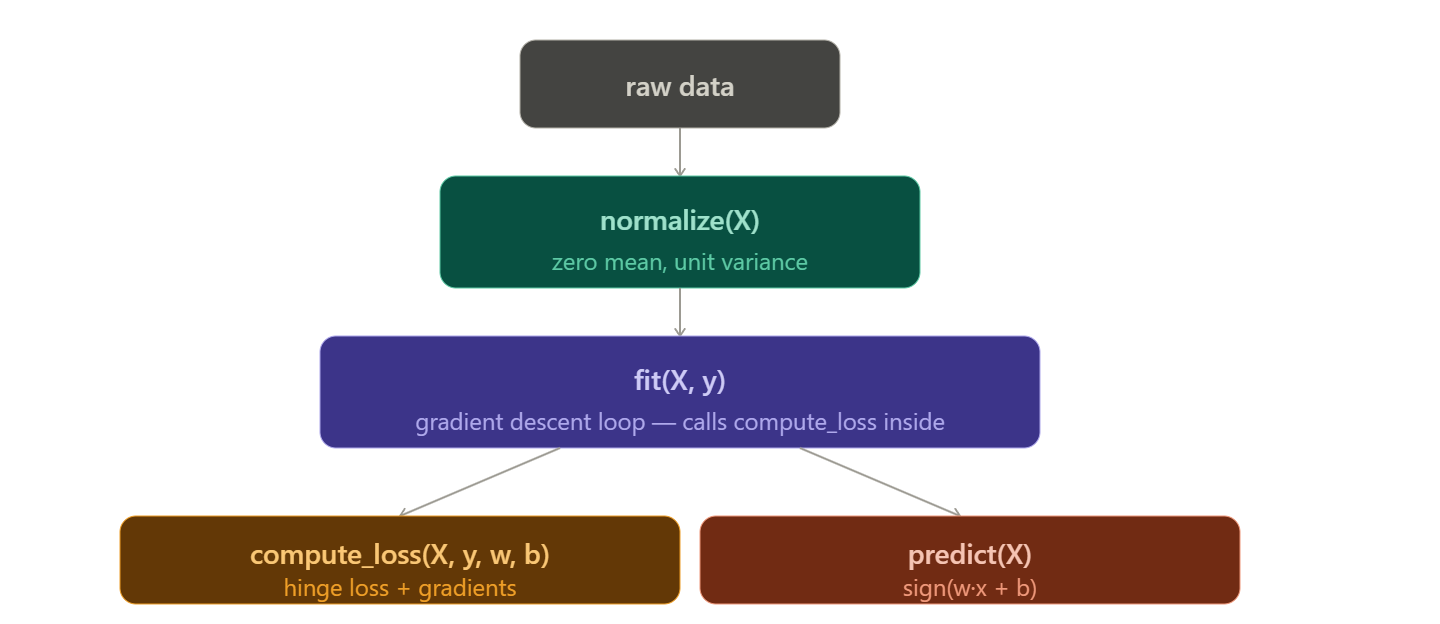

In [15]:
def normalize(X):
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0)
    std[std == 0] = 1
    return (X - mean) / std, mean, std

def fit(X, y, C=50.0, lr=0.001, n_iters=1000):
    n_samples, n_features = X.shape
    y_ = np.where(y <= 0, -1, 1).astype(float)
    w = np.zeros(n_features)
    b = 0.0
    for epoch in range(n_iters):
        for idx, x_i in enumerate(X):
            condition = y_[idx] * (np.dot(x_i, w) - b) >= 1
            if condition:
                w -= lr * (2 * (1/(2*n_samples)) * w)
            else:
                w -= lr * (2 * (1/(2*n_samples)) * w - C * np.dot(x_i, y_[idx]))
                b -= lr * C * y_[idx]
    return w, b

def predict(X, w, b):
    return np.where(np.dot(X, w) - b >= 0, 1, 0)

def metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    acc  = np.mean(y_pred == y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    return acc, prec, rec, f1

def predict_patient(patient_dict, feature_cols, w, b, mean, std):
    x = np.array([patient_dict[c] for c in feature_cols], dtype=float)
    x = (x - mean) / std
    return "Heart Disease" if predict(x.reshape(1,-1), w, b)[0] == 1 else "No Heart Disease"

# ── data ──
df = pd.read_csv("heart.csv")
X  = df.drop("target", axis=1).values.astype(float)
y  = df["target"].values.astype(float)

np.random.seed(42)
idx   = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

X_train_n, mean, std = normalize(X_train)
X_test_n = (X_test - mean) / std

# ── train with best C ──
w, b = fit(X_train_n, y_train, C=50.0, lr=0.001, n_iters=1000)
y_pred = predict(X_test_n, w, b)
acc, prec, rec, f1 = metrics(y_test, y_pred)

print("=" * 42)
print("      FINAL RESULTS  (C=50)")
print("=" * 42)
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print("=" * 42)

      FINAL RESULTS  (C=50)
  Accuracy   : 0.8488
  Precision  : 0.8713
  Recall     : 0.8302
  F1-Score   : 0.8502


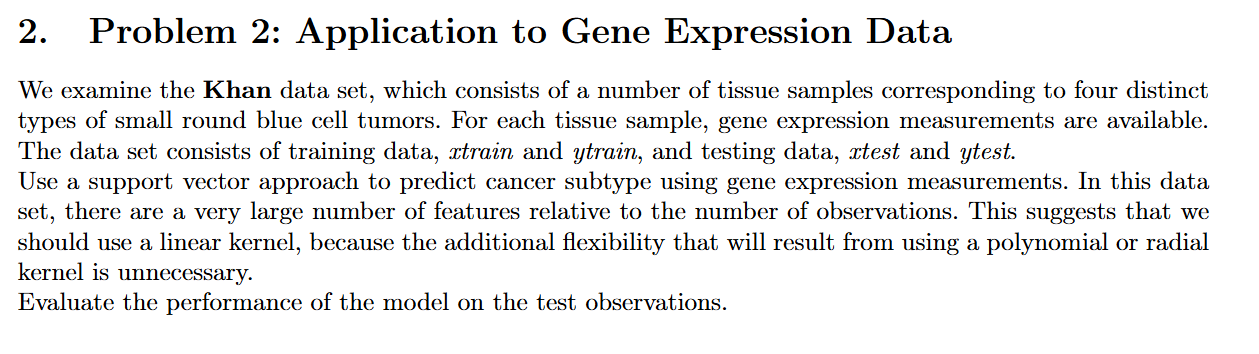

In [16]:
X_train = pd.read_csv('Khan_xtrain.csv')
X_test = pd.read_csv('Khan_xtest.csv')
y_train = pd.read_csv('Khan_ytrain.csv')
y_test = pd.read_csv('Khan_ytest.csv')

In [17]:
X_train = X_train.drop(columns=['Unnamed: 0'])
X_test = X_test.drop(columns=['Unnamed: 0'])
y_train = y_train.drop(columns=['Unnamed: 0'])
y_test = y_test.drop(columns=['Unnamed: 0'])

In [18]:
X_train_n, mean, std = normalize(X_train)
X_test_n = (X_test - mean) / std

# ── train with best C ──
w, b = fit(X_train_n, y_train, C=50.0, lr=0.001, n_iters=1000)
y_pred = predict(X_test_n, w, b)
acc, prec, rec, f1 = metrics(y_test, y_pred)

print("=" * 42)
print("      FINAL RESULTS  (C=50)")
print("=" * 42)
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print("=" * 42)

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U2'), dtype('<U32')) -> None